```python
S = sandpiles.Grid(3,3)
S.group_order()
S.group_gens(verbose=False)
```


In [11]:
from sage.all import *
import numpy as np
from matplotlib import pyplot as plt

In [169]:
S = sandpiles.Grid(3,3)
print(S.group_order())
print(S.group_gens(verbose=False))
print(S.identity(verbose=False))

100352
[[2, 1, 1, 3, 1, 3, 1, 1, 2], [2, 1, 2, 1, 0, 1, 2, 2, 2], [2, 1, 2, 1, 0, 1, 2, 1, 3]]
[2, 1, 2, 1, 0, 1, 2, 1, 2]


In [285]:
#S.recurrents()
S.invariant_factors()

[1, 1, 1, 1, 1, 1, 4, 112, 224]

In [13]:
def do_add( spile, tumbled ):
    """ Updates spile in place """
    spile[ :-1, :] += tumbled[ 1:, :] # Shift N and add                 
    spile[ 1:, :] += tumbled[ :-1, :] # Shift S   
    spile[ :, :-1] += tumbled[ :, 1:] # Shift W
    spile[ :, 1:] += tumbled[ :, :-1] # Shift E

def tumble( spile ):
    while ( spile > 3 ).any():
        tumbled, spile = np.divmod( spile, 4 )
        do_add( spile, tumbled )
        # print( spile, '\n' )  # Uncomment to print steps
    return spile

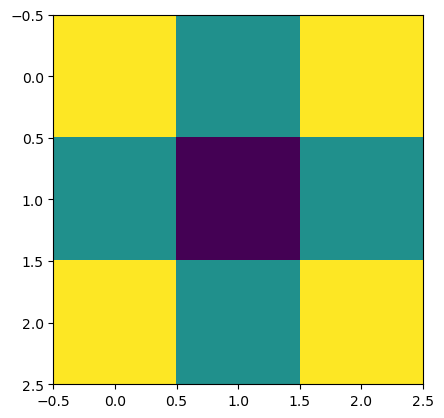

In [330]:
id3 = np.array([2, 1, 2, 1, 0, 1, 2, 1, 2]).reshape(3,3)
plt.imshow(id3, interpolation='nearest');plt.show()

In [301]:
m1 = np.array([2, 1, 1, 3, 1, 3, 1, 1, 2]).reshape(3,3)
m2 = np.array([2, 1, 2, 1, 0, 1, 2, 2, 2]).reshape(3,3)
m3 = np.array([2, 1, 2, 1, 0, 1, 2, 1, 3]).reshape(3,3)


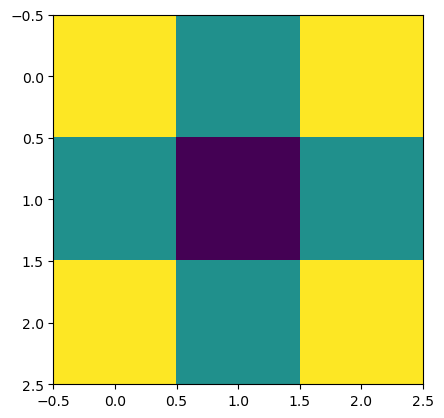

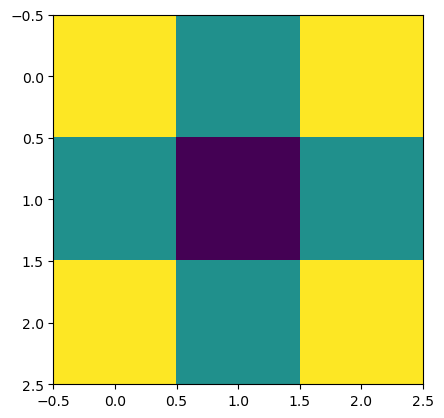

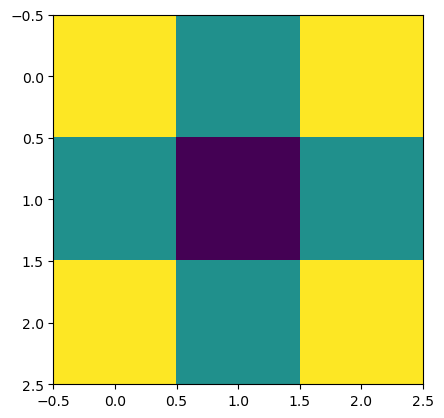

In [311]:
plt.imshow(tumble(4*m1), interpolation='nearest');plt.show()
plt.imshow(tumble(112*m2), interpolation='nearest');plt.show()
plt.imshow(tumble(224*m3), interpolation='nearest');plt.show()

In [318]:
for a in range(2):
    print(a)

0
1


In [342]:
elems = []
for a in range(1, 225):
  for b in range(1, 113):
    for c in range(1, 5):
      elems.append(tumble(a*m1 + b*m2 + c*m3))


In [343]:
np.save("3x3elems", elems)

In [324]:
len(elems)

100352

In [347]:
elemr = elems[np.random.randint(0,100352)]
tumble(elemr + id3)-elemr


array([[0, 0, 0],
       [0, 0, 0],
       [0, 0, 0]])